# PRÁCTICA CLASE 6 - TEMAS AVANZADOS EN TRANSFORMERS

Elementos:
1. Fine-tuning eficiente con LoRA / PEFT (opcional, con Hugging Face).
2. Cuantización dinámica INT8 en PyTorch.
3. Medición de tamaño, latencia, throughput y accuracy.
4. Exportación a ONNX y ejecución con ONNX Runtime (opcional).
5. Plantillas conceptuales para GPTQ, AWQ y vLLM.

## Instalación base recomendada:
pip install -U torch scikit-learn pandas matplotlib

## Instalación opcional para LoRA / Hugging Face:
pip install -U transformers datasets accelerate peft

## Instalación opcional para ONNX:
pip install -U onnx onnxruntime

In [1]:
!pip install -U torch scikit-learn pandas matplotlib
!pip install -U transformers datasets accelerate peft
!pip install -U onnx onnxruntime

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 3.50.2 requires pandas<3.0,>=1.0, but you have pandas 3.0.3 which is incompatible.
sklearn-compat 0.1.5 requires scikit-learn<1.9,>=1.2, but you have scikit-learn 1.9.0 which is incompatible.
tensorflow-intel 2.16.1 requires ml-dtypes~=0.3.1, but you have ml-dtypes 0.5.4 which is incompatible.
tensorflow-intel 2.16.1 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.20.3, but you have protobuf 7.35.1 which is incompatible.
torchvision 0.27.0 requires torch==2.12.0, but you have torch 2.13.0 which is incompatible.



   ---------------------------------------- 0.0/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.8/122.1 MB 2.4 MB/s eta 0:00:51
   ---------------------------------------- 1.3/122.1 MB 2.3 MB/s eta 0:00:53
    --------------------------------------- 1.8/122.1 MB 2.3 MB/s eta 0:00:52
    --------------------------------------- 2.4/122.1 MB 2.4 MB/s eta 0:00:51
    --------------------------------------- 2.9/122.1 MB 2.3 MB/s eta 0:00:52
   - -------------------------------------- 3.4/122.1 MB 2.3 MB/s eta 0:00:51
   - -------------------------------------- 3.9/122.1 MB 2.3 MB/s eta 0:00:51
   - -------------------------------------- 4.2/122.1 MB 2.3 MB/s eta 0:00:51
   - -------------------------------------- 4.7/122.1 MB 2.3 MB/s eta 0:00:51
   - -------------------------------------- 5.2/122.1 MB 2.3 MB/s eta 0:00:51
   - -------------------------------------- 5.8/122.1 MB 2.3 MB/s eta 0:00:51

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 3.50.2 requires pandas<3.0,>=1.0, but you have pandas 3.0.3 which is incompatible.
hf-gradio 0.4.1 requires gradio-client<3.0,>=2.0, but you have gradio-client 0.6.1 which is incompatible.


   ---------------------------------------- 0.0/17.2 MB ? eta -:--:--
   - -------------------------------------- 0.5/17.2 MB 3.4 MB/s eta 0:00:05
   -- ------------------------------------- 1.0/17.2 MB 3.4 MB/s eta 0:00:05
   ---- ----------------------------------- 1.8/17.2 MB 3.5 MB/s eta 0:00:05
   ------ --------------------------------- 2.6/17.2 MB 3.4 MB/s eta 0:00:05
   ------- -------------------------------- 3.4/17.2 MB 3.4 MB/s eta 0:00:05
   --------- ------------------------------ 4.2/17.2 MB 3.4 MB/s eta 0:00:04
   ----------- ---------------------------- 5.0/17.2 MB 3.4 MB/s eta 0:00:04
   ------------- -------------------------- 5.8/17.2 MB 3.5 MB/s eta 0:00:04
   -------------- ------------------------- 6.3/17.2 MB 3.5 MB/s eta 0:00:04
   ---------------- ----------------------- 7.1/17.2 MB 3.5 MB/s eta 0:00:03
   ------------------ --------------------- 7.9/17.2 MB 3.5 MB/s eta 0:00:03
   -------------------- ------------------- 8.7/17.2 MB 3.5 MB/s eta 0:00:03
   ---

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 3.50.2 requires pandas<3.0,>=1.0, but you have pandas 3.0.3 which is incompatible.
hf-gradio 0.4.1 requires gradio-client<3.0,>=2.0, but you have gradio-client 0.6.1 which is incompatible.
tensorflow-intel 2.16.1 requires ml-dtypes~=0.3.1, but you have ml-dtypes 0.5.4 which is incompatible.
tensorflow-intel 2.16.1 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.20.3, but you have protobuf 7.35.1 which is incompatible.
torchvision 0.27.0 requires torch==2.12.0, but you have torch 2.13.0 which is incompatible.


In [15]:
!pip install onnxscript

   ---------------------------------------- 0.0/722.0 kB ? eta -:--:--
   -------------- ------------------------- 262.1/722.0 kB ? eta -:--:--
   ---------------------------------------- 722.0/722.0 kB 3.3 MB/s  0:00:00

   ---------------------------------------- 0/2 [onnx_ir]
   ---------------------------------------- 0/2 [onnx_ir]
   ---------------------------------------- 0/2 [onnx_ir]
   ---------------------------------------- 0/2 [onnx_ir]
   ---------------------------------------- 0/2 [onnx_ir]
   ---------------------------------------- 0/2 [onnx_ir]
   ---------------------------------------- 0/2 [onnx_ir]
   ---------------------------------------- 0/2 [onnx_ir]
   -------------------- ------------------- 1/2 [onnxscript]
   -------------------- ------------------- 1/2 [onnxscript]
   -------------------- ------------------- 1/2 [onnxscript]
   -------------------- ------------------- 1/2 [onnxscript]
   -------------------- ------------------- 1/2 [onnxscript]
   ------

In [2]:
# Importar librerías

import os
import time
import random
import tempfile
import inspect
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

Matplotlib is building the font cache; this may take a moment.


In [3]:
# ============================================================
# 0. CONFIGURACIÓN GENERAL
# ============================================================

SEED = 666
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

torch.set_num_threads(1)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

OUTPUT_DIR = Path("resultados_practica_clase_6")
OUTPUT_DIR.mkdir(exist_ok=True)

# Ajustes de práctica
FAST_MODE = True

# Ejecuta fine-tuning LoRA con Hugging Face si hay internet y dependencias.
# Si falla, el script continúa con las secciones locales.
RUN_HF_LORA = True

# Ejecuta ONNX si onnx y onnxruntime están instalados.
RUN_ONNX_DEMO = True

# Modelo recomendado para LoRA en CPU/GPU pequeña.
# Puedes cambiarlo por: "dccuchile/bert-base-spanish-wwm-cased"
# si tienes más recursos.
HF_MODEL_NAME = "distilbert-base-multilingual-cased"

if FAST_MODE:
    HF_EPOCHS = 1
    LOCAL_EPOCHS = 80
else:
    HF_EPOCHS = 2
    LOCAL_EPOCHS = 150

LABELS = {0: "negativo", 1: "neutro", 2: "positivo"}
ID2LABEL = LABELS
LABEL2ID = {v: k for k, v in LABELS.items()}

In [4]:
# ============================================================
# 1. DATASET LOCAL EN ESPAÑOL
# ============================================================

DATA = [
    # Positivos
    ("Me encantó el curso, aprendí muchísimo.", 2),
    ("La explicación fue clara y muy útil.", 2),
    ("Estoy muy satisfecho con el resultado.", 2),
    ("El servicio fue excelente y rápido.", 2),
    ("La película me pareció maravillosa.", 2),
    ("El producto superó mis expectativas.", 2),
    ("La atención fue amable y profesional.", 2),
    ("Me siento feliz con esta experiencia.", 2),
    ("El material está muy bien organizado.", 2),
    ("La clase fue dinámica e interesante.", 2),
    ("El sistema funciona perfectamente.", 2),
    ("La comida estuvo deliciosa.", 2),
    ("Recomendaría este servicio sin dudarlo.", 2),
    ("El equipo hizo un gran trabajo.", 2),
    ("La aplicación es intuitiva y útil.", 2),
    ("La práctica fue interesante y formativa.", 2),
    ("El tutorial me ayudó bastante.", 2),
    ("El modelo funcionó mejor de lo esperado.", 2),
    ("La solución fue sencilla y efectiva.", 2),
    ("El profesor explicó el tema con mucha paciencia.", 2),
    ("El proyecto quedó muy bien documentado.", 2),
    ("La demostración fue convincente.", 2),
    ("La transcripción fue precisa.", 2),
    ("El resumen fue claro y coherente.", 2),
    ("La clasificación fue correcta.", 2),

    # Neutros
    ("El curso inicia a las nueve de la mañana.", 1),
    ("La reunión será en el aula principal.", 1),
    ("El documento contiene cinco secciones.", 1),
    ("La computadora tiene ocho gigabytes de memoria.", 1),
    ("El archivo se guardó en la carpeta indicada.", 1),
    ("La clase tendrá una duración de cuatro horas.", 1),
    ("El sistema muestra una pantalla de inicio.", 1),
    ("El informe fue enviado ayer.", 1),
    ("La actividad consiste en clasificar textos.", 1),
    ("El dataset contiene ejemplos en español.", 1),
    ("El modelo se entrenará durante varias épocas.", 1),
    ("El examen tendrá preguntas de opción múltiple.", 1),
    ("La práctica utiliza una biblioteca de aprendizaje automático.", 1),
    ("La tabla muestra los resultados obtenidos.", 1),
    ("El archivo incluye los datos de entrenamiento.", 1),
    ("La sesión termina a las dos de la tarde.", 1),
    ("El programa imprime las métricas finales.", 1),
    ("El usuario escribió un comentario corto.", 1),
    ("El modelo recibe una oración como entrada.", 1),
    ("La evaluación se realizó con el conjunto de prueba.", 1),
    ("La carpeta contiene los archivos generados.", 1),
    ("La gráfica muestra la pérdida por época.", 1),
    ("El script crea una tabla comparativa.", 1),
    ("El modelo fue exportado a otro formato.", 1),
    ("El reporte contiene resultados y conclusiones.", 1),

    # Negativos
    ("No me gustó la explicación, fue confusa.", 0),
    ("El servicio fue lento y deficiente.", 0),
    ("Estoy decepcionado con el resultado.", 0),
    ("La aplicación falla constantemente.", 0),
    ("La película fue aburrida y larga.", 0),
    ("El producto llegó dañado.", 0),
    ("La atención fue grosera.", 0),
    ("Me siento frustrado con esta experiencia.", 0),
    ("El material está desordenado.", 0),
    ("La clase fue tediosa.", 0),
    ("El sistema no funciona correctamente.", 0),
    ("La comida estuvo fría y sin sabor.", 0),
    ("No recomendaría este servicio.", 0),
    ("El equipo entregó un trabajo incompleto.", 0),
    ("La aplicación es difícil de usar.", 0),
    ("La presentación fue poco clara.", 0),
    ("La respuesta fue lenta e imprecisa.", 0),
    ("El ambiente fue incómodo.", 0),
    ("La experiencia fue negativa.", 0),
    ("Estoy molesto con la compra.", 0),
    ("La instalación fue complicada y falló varias veces.", 0),
    ("El resultado no fue el esperado.", 0),
    ("El tutorial está mal explicado.", 0),
    ("La práctica fue confusa.", 0),
    ("El modelo cometió demasiados errores.", 0),
]

random.shuffle(DATA)
TEXTS = [x[0] for x in DATA]
Y = np.array([x[1] for x in DATA], dtype=np.int64)

train_texts, temp_texts, y_train, y_temp = train_test_split(
    TEXTS, Y, test_size=0.30, random_state=SEED, stratify=Y
)
val_texts, test_texts, y_val, y_test = train_test_split(
    temp_texts, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print("\nTamaño del dataset local:")
print("Train:", len(train_texts), "Validation:", len(val_texts), "Test:", len(test_texts))


Tamaño del dataset local:
Train: 52 Validation: 11 Test: 12


In [5]:
# ============================================================
# 2. UTILIDADES GENERALES
# ============================================================

def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


def model_size_mb(model):
    """Calcula tamaño aproximado del state_dict guardado."""
    with tempfile.NamedTemporaryFile(suffix=".pt", delete=False) as tmp:
        path = tmp.name
    try:
        torch.save(model.state_dict(), path)
        size_mb = os.path.getsize(path) / (1024 ** 2)
    finally:
        if os.path.exists(path):
            os.remove(path)
    return size_mb


def save_dataframe(df, name):
    path = OUTPUT_DIR / name
    df.to_csv(path, index=False, encoding="utf-8")
    print("Archivo guardado:", path)
    return path

In [13]:
# ============================================================
# 3. BLOQUE OPCIONAL: LoRA / PEFT CON HUGGING FACE
# ============================================================


def run_lora_huggingface():
    print("\n" + "=" * 70)
    print("BLOQUE 1 - LoRA / PEFT con Hugging Face")
    print("=" * 70)

    try:
        from datasets import Dataset, DatasetDict
        from transformers import (
            AutoTokenizer,
            AutoModelForSequenceClassification,
            DataCollatorWithPadding,
            Trainer,
            TrainingArguments,
            set_seed,
        )
        from peft import LoraConfig, TaskType, get_peft_model
    except Exception as e:
        print("No se pudo importar transformers/datasets/peft.")
        print("Instala con:")
        print("pip install -U transformers datasets accelerate peft")
        print("Detalle:", e)
        return None

    set_seed(SEED)

    train_ds = Dataset.from_dict({"text": train_texts, "label": list(map(int, y_train))})
    val_ds = Dataset.from_dict({"text": val_texts, "label": list(map(int, y_val))})
    test_ds = Dataset.from_dict({"text": test_texts, "label": list(map(int, y_test))})
    dataset = DatasetDict({"train": train_ds, "validation": val_ds, "test": test_ds})

    try:
        tokenizer = AutoTokenizer.from_pretrained(HF_MODEL_NAME, use_fast=True)
        base_model = AutoModelForSequenceClassification.from_pretrained(
            HF_MODEL_NAME,
            num_labels=3,
            id2label=ID2LABEL,
            label2id=LABEL2ID,
        )
    except Exception as e:
        print("No se pudo descargar o cargar el modelo de Hugging Face.")
        print("Revisa conexión a internet o usa un modelo ya cacheado.")
        print("Modelo solicitado:", HF_MODEL_NAME)
        print("Detalle:", e)
        return None

    model_type = getattr(base_model.config, "model_type", "unknown")
    if model_type == "distilbert":
        target_modules = ["q_lin", "v_lin"]
    elif model_type in ["bert", "roberta", "deberta-v2"]:
        target_modules = ["query", "value"]
    else:
        target_modules = ["query", "value"]

    print("Modelo base:", HF_MODEL_NAME)
    print("Tipo de modelo:", model_type)
    print("Módulos objetivo LoRA:", target_modules)

    def tokenize(batch):
        return tokenizer(batch["text"], truncation=True, max_length=96)

    tokenized = dataset.map(tokenize, batched=True)
    tokenized = tokenized.rename_column("label", "labels")
    cols_to_remove = [
        c for c in tokenized["train"].column_names
        if c not in ["input_ids", "attention_mask", "token_type_ids", "labels"]
    ]
    tokenized = tokenized.remove_columns(cols_to_remove)

    lora_config = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        r=8,
        lora_alpha=16,
        lora_dropout=0.10,
        bias="none",
        target_modules=target_modules,
    )

    model = get_peft_model(base_model, lora_config)

    total, trainable = count_parameters(model)
    print(f"Parámetros totales: {total:,}")
    print(f"Parámetros entrenables con LoRA: {trainable:,}")
    print(f"Porcentaje entrenable: {100 * trainable / total:.4f}%")

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        return {
            "accuracy": accuracy_score(labels, preds),
            "f1_macro": f1_score(labels, preds, average="macro", zero_division=0),
        }

    params = inspect.signature(TrainingArguments.__init__).parameters
    args = {
        "output_dir": str(OUTPUT_DIR / "hf_lora"),
        "learning_rate": 2e-4,
        "per_device_train_batch_size": 8,
        "per_device_eval_batch_size": 16,
        "num_train_epochs": HF_EPOCHS,
        "weight_decay": 0.01,
        "logging_steps": 5,
        "save_strategy": "no",
        "report_to": "none",
        "seed": SEED,
        "fp16": torch.cuda.is_available(),
    }
    if "eval_strategy" in params:
        args["eval_strategy"] = "epoch"
    else:
        args["evaluation_strategy"] = "epoch"

    training_args = TrainingArguments(**args)
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized["train"],
        eval_dataset=tokenized["validation"],
        #tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    start = time.perf_counter()
    trainer.train()
    runtime = time.perf_counter() - start

    print(f"Tiempo de entrenamiento LoRA: {runtime:.2f} s")

    test_output = trainer.predict(tokenized["test"])
    preds = np.argmax(test_output.predictions, axis=-1)
    labels = test_output.label_ids

    print("\nReporte LoRA en test:")
    print(classification_report(labels, preds, target_names=[LABELS[i] for i in range(3)], zero_division=0))
    print("Matriz de confusión:")
    print(confusion_matrix(labels, preds))

    result = {
        "experimento": "HF_LoRA_PEFT",
        "modelo": HF_MODEL_NAME,
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro", zero_division=0),
        "runtime_seg": runtime,
        "params_totales": total,
        "params_entrenables": trainable,
        "porcentaje_entrenable": 100 * trainable / total,
    }

    pd.DataFrame([result]).to_csv(OUTPUT_DIR / "resultado_hf_lora.csv", index=False, encoding="utf-8")
    print("Resultado LoRA guardado en:", OUTPUT_DIR / "resultado_hf_lora.csv")

    print("\nPreguntas para discusión LoRA:")
    print("1. ¿Qué porcentaje del modelo se entrenó realmente?")
    print("2. ¿Qué se gana y qué se pierde al no actualizar todos los pesos?")
    print("3. ¿LoRA sería justificable en un proyecto de 20 días? ¿Por qué?")

    return result

In [7]:
# ============================================================
# 4. MODELO LOCAL PARA CUANTIZACIÓN E INFERENCIA
# ============================================================


def simple_tokenize(text):
    text = text.lower()
    for ch in ".,;:¡!¿?()[]{}\"'":
        text = text.replace(ch, " ")
    return text.split()


def build_vocab(texts, min_freq=1):
    counter = Counter()
    for text in texts:
        counter.update(simple_tokenize(text))
    vocab = {"<unk>": 0}
    for tok, freq in sorted(counter.items()):
        if freq >= min_freq:
            vocab[tok] = len(vocab)
    return vocab


VOCAB = build_vocab(train_texts)


def vectorize_texts(texts, vocab):
    X = torch.zeros((len(texts), len(vocab)), dtype=torch.float32)
    for i, text in enumerate(texts):
        tokens = simple_tokenize(text)
        if not tokens:
            continue
        for tok in tokens:
            idx = vocab.get(tok, vocab["<unk>"])
            X[i, idx] += 1.0
        X[i] = X[i] / max(1.0, X[i].sum())
    return X


X_train = vectorize_texts(train_texts, VOCAB)
X_val = vectorize_texts(val_texts, VOCAB)
X_test = vectorize_texts(test_texts, VOCAB)
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_val_t = torch.tensor(y_val, dtype=torch.long)
y_test_t = torch.tensor(y_test, dtype=torch.long)


class TinyTextClassifier(nn.Module):
    """Clasificador pequeño para demostrar cuantización y ONNX.

    Este modelo no pretende competir con BERT. Se usa como laboratorio
    controlado para medir tamaño, latencia, throughput y exportación.
    """

    def __init__(self, input_dim, hidden_dim=64, num_classes=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.10),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        return self.net(x)


def train_local_model():
    print("\n" + "=" * 70)
    print("BLOQUE 2 - Baseline local para cuantización")
    print("=" * 70)

    model = TinyTextClassifier(input_dim=len(VOCAB)).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()

    history = []
    Xtr, ytr = X_train.to(DEVICE), y_train_t.to(DEVICE)
    Xv, yv = X_val.to(DEVICE), y_val_t.to(DEVICE)

    for epoch in range(1, LOCAL_EPOCHS + 1):
        model.train()
        optimizer.zero_grad()
        logits = model(Xtr)
        loss = criterion(logits, ytr)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            train_pred = model(Xtr).argmax(dim=1).cpu().numpy()
            val_logits = model(Xv)
            val_loss = criterion(val_logits, yv).item()
            val_pred = val_logits.argmax(dim=1).cpu().numpy()

        history.append({
            "epoch": epoch,
            "train_loss": loss.item(),
            "val_loss": val_loss,
            "train_acc": accuracy_score(y_train, train_pred),
            "val_acc": accuracy_score(y_val, val_pred),
        })

        if epoch == 1 or epoch % 20 == 0:
            print(f"Epoch {epoch:03d} | train_loss={loss.item():.4f} | val_loss={val_loss:.4f} | val_acc={accuracy_score(y_val, val_pred):.3f}")

    df_hist = pd.DataFrame(history)
    save_dataframe(df_hist, "historial_entrenamiento_modelo_local.csv")

    plt.figure(figsize=(8, 5))
    plt.plot(df_hist["epoch"], df_hist["train_loss"], label="train loss")
    plt.plot(df_hist["epoch"], df_hist["val_loss"], label="validation loss")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.title("Curva de aprendizaje - modelo local")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "curva_modelo_local.png", dpi=150)
    plt.show()

    return model


def evaluate_torch_model(model, X, y, name="modelo"):
    model.eval()
    X_dev = X.to(next(model.parameters()).device) if any(True for _ in model.parameters()) else X
    with torch.no_grad():
        logits = model(X_dev)
        preds = logits.argmax(dim=1).cpu().numpy()
    acc = accuracy_score(y, preds)
    f1 = f1_score(y, preds, average="macro", zero_division=0)
    print(f"\nEvaluación {name}: accuracy={acc:.4f}, f1_macro={f1:.4f}")
    print(classification_report(y, preds, target_names=[LABELS[i] for i in range(3)], zero_division=0))
    return acc, f1, preds


def measure_latency(model, X, repeats=200, batch_size=1, name="modelo"):
    model.eval()
    model_cpu = model.to("cpu")
    X_cpu = X.to("cpu")

    # Crear batches repetibles
    batches = []
    n = len(X_cpu)
    for i in range(0, n, batch_size):
        batches.append(X_cpu[i:i+batch_size])

    # Warmup
    with torch.no_grad():
        for batch in batches:
            _ = model_cpu(batch)

    start = time.perf_counter()
    total_examples = 0
    with torch.no_grad():
        for _ in range(repeats):
            for batch in batches:
                _ = model_cpu(batch)
                total_examples += batch.shape[0]
    elapsed = time.perf_counter() - start

    latency_ms_per_batch = 1000 * elapsed / (repeats * len(batches))
    throughput = total_examples / elapsed

    print(f"{name} | batch={batch_size} | latencia/batch={latency_ms_per_batch:.4f} ms | throughput={throughput:.2f} ejemplos/s")

    return latency_ms_per_batch, throughput

In [8]:
# ============================================================
# 5. CUANTIZACIÓN DINÁMICA INT8
# ============================================================


def run_quantization_demo(model_fp32):
    print("\n" + "=" * 70)
    print("BLOQUE 3 - Cuantización dinámica INT8")
    print("=" * 70)

    model_fp32 = model_fp32.to("cpu")
    acc_fp32, f1_fp32, _ = evaluate_torch_model(model_fp32, X_test, y_test, name="FP32")
    size_fp32 = model_size_mb(model_fp32)

    model_int8 = torch.quantization.quantize_dynamic(
        model_fp32,
        {nn.Linear},
        dtype=torch.qint8
    )

    acc_int8, f1_int8, _ = evaluate_torch_model(model_int8, X_test, y_test, name="INT8 cuantizado")
    size_int8 = model_size_mb(model_int8)

    lat_fp32, thr_fp32 = measure_latency(model_fp32, X_test, repeats=200, batch_size=1, name="FP32")
    lat_int8, thr_int8 = measure_latency(model_int8, X_test, repeats=200, batch_size=1, name="INT8")

    results = pd.DataFrame([
        {
            "modelo": "FP32",
            "accuracy": acc_fp32,
            "f1_macro": f1_fp32,
            "size_mb": size_fp32,
            "latencia_ms_batch1": lat_fp32,
            "throughput_ej_s": thr_fp32,
        },
        {
            "modelo": "INT8_dynamic",
            "accuracy": acc_int8,
            "f1_macro": f1_int8,
            "size_mb": size_int8,
            "latencia_ms_batch1": lat_int8,
            "throughput_ej_s": thr_int8,
        }
    ])

    save_dataframe(results, "comparacion_cuantizacion.csv")
    print("\nComparación FP32 vs INT8:")
    print(results)

    plt.figure(figsize=(8, 5))
    plt.bar(results["modelo"], results["size_mb"])
    plt.ylabel("Tamaño aproximado en MB")
    plt.title("Reducción de tamaño por cuantización")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "cuantizacion_tamano.png", dpi=150)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.bar(results["modelo"], results["throughput_ej_s"])
    plt.ylabel("Throughput, ejemplos/s")
    plt.title("Throughput de inferencia")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "cuantizacion_throughput.png", dpi=150)
    plt.show()

    print("\nPreguntas para discusión de cuantización:")
    print("1. ¿El modelo INT8 redujo el tamaño? ¿Cuánto?")
    print("2. ¿Se mantuvo accuracy y F1 macro?")
    print("3. ¿La inferencia fue más rápida en este equipo?")
    print("4. ¿Por qué una técnica puede ayudar en un hardware y no en otro?")

    return model_int8, results

In [9]:
# ============================================================
# 6. BATCHING Y THROUGHPUT
# ============================================================


def run_batching_demo(model):
    print("\n" + "=" * 70)
    print("BLOQUE 4 - Inferencia optimizada: batching y throughput")
    print("=" * 70)

    rows = []
    for batch_size in [1, 2, 4, 8, 16]:
        lat, thr = measure_latency(model, X_test, repeats=250, batch_size=batch_size, name="FP32")
        rows.append({"batch_size": batch_size, "latencia_ms_por_batch": lat, "throughput_ej_s": thr})

    df = pd.DataFrame(rows)
    save_dataframe(df, "batching_throughput.csv")
    print(df)

    plt.figure(figsize=(8, 5))
    plt.plot(df["batch_size"], df["throughput_ej_s"], marker="o")
    plt.xlabel("Batch size")
    plt.ylabel("Throughput, ejemplos/s")
    plt.title("Efecto del batching sobre throughput")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "batching_throughput.png", dpi=150)
    plt.show()

    print("\nPreguntas para discusión de batching:")
    print("1. ¿Aumentó el throughput al incrementar el batch?")
    print("2. ¿Qué diferencia hay entre latencia individual y throughput global?")
    print("3. ¿En qué escenarios conviene batch grande y en cuáles no?")

    return df

In [10]:
# ============================================================
# 7. ONNX Y ONNX RUNTIME
# ============================================================


def run_onnx_demo(model_fp32):
    print("\n" + "=" * 70)
    print("BLOQUE 5 - ONNX y ONNX Runtime")
    print("=" * 70)

    try:
        import onnx  # noqa: F401
        import onnxruntime as ort
    except Exception as e:
        print("ONNX u ONNX Runtime no están instalados.")
        print("Instala con:")
        print("pip install -U onnx onnxruntime")
        print("Detalle:", e)
        return None

    model_fp32 = model_fp32.to("cpu")
    model_fp32.eval()

    onnx_path = OUTPUT_DIR / "tiny_text_classifier.onnx"
    dummy_input = torch.zeros((1, len(VOCAB)), dtype=torch.float32)

    torch.onnx.export(
        model_fp32,
        dummy_input,
        onnx_path,
        input_names=["input"],
        output_names=["logits"],
        dynamic_axes={"input": {0: "batch"}, "logits": {0: "batch"}},
        opset_version=13,
    )

    print("Modelo exportado a ONNX:", onnx_path)

    session = ort.InferenceSession(str(onnx_path), providers=["CPUExecutionProvider"])
    input_name = session.get_inputs()[0].name

    X_np = X_test.numpy().astype(np.float32)

    # Warmup
    for _ in range(5):
        _ = session.run(None, {input_name: X_np})

    start = time.perf_counter()
    repeats = 300
    for _ in range(repeats):
        logits = session.run(None, {input_name: X_np})[0]
    elapsed = time.perf_counter() - start

    preds = logits.argmax(axis=1)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average="macro", zero_division=0)
    throughput = (len(X_np) * repeats) / elapsed

    print(f"ONNX Runtime | accuracy={acc:.4f} | f1_macro={f1:.4f} | throughput={throughput:.2f} ejemplos/s")

    result = pd.DataFrame([
        {
            "formato": "ONNX_Runtime_CPU",
            "accuracy": acc,
            "f1_macro": f1,
            "throughput_ej_s": throughput,
            "archivo": str(onnx_path),
        }
    ])
    save_dataframe(result, "resultado_onnx_runtime.csv")

    print("\nPreguntas para discusión ONNX:")
    print("1. ¿La salida ONNX conserva la misma calidad que PyTorch?")
    print("2. ¿Qué ventajas tiene un formato portable?")
    print("3. ¿Qué habría que validar antes de usar ONNX en producción?")

    return result

In [11]:
# ============================================================
# 8. PLANTILLAS CONCEPTUALES: GPTQ, AWQ Y vLLM
# ============================================================


def print_advanced_templates():
    print("\n" + "=" * 70)
    print("BLOQUE 6 - Plantillas conceptuales para GPTQ, AWQ y vLLM")
    print("=" * 70)

    print(r'''
[Plantilla conceptual: GPTQ]
- Se usa principalmente como cuantización post-entrenamiento para LLMs.
- Flujo típico:
    1. Cargar modelo ya entrenado.
    2. Proporcionar datos de calibración.
    3. Cuantizar pesos a 4-bit u 8-bit.
    4. Evaluar calidad, memoria y latencia.

Ejemplo orientativo, NO ejecutado aquí:

from transformers import AutoModelForCausalLM, AutoTokenizer, GPTQConfig

model_id = "modelo-causal-compatible"
quant_config = GPTQConfig(bits=4, dataset="c4", tokenizer=AutoTokenizer.from_pretrained(model_id))
model = AutoModelForCausalLM.from_pretrained(model_id, quantization_config=quant_config)
''')

    print(r'''
[Plantilla conceptual: AWQ]
- Activation-aware Weight Quantization protege pesos sensibles según activaciones.
- Se usa sobre todo en LLMs para inferencia eficiente.
- Debe validarse con prompts reales del dominio del proyecto.

Ejemplo orientativo, NO ejecutado aquí:

# Normalmente se usa con herramientas externas o checkpoints ya cuantizados.
# Buscar en Model Hub: modelos con sufijo AWQ.
# Ejemplo de uso típico con un checkpoint AWQ dependerá del runtime elegido.
''')

    print(r'''
[Plantilla conceptual: vLLM]
- Motor de inferencia para servir LLMs con alta eficiencia.
- Su idea conocida es PagedAttention para gestionar KV cache.
- Útil cuando hay varias solicitudes concurrentes o generación intensiva.

Ejemplo orientativo, NO ejecutado aquí:

# pip install vllm
# python -m vllm.entrypoints.openai.api_server \
#     --model meta-llama/Llama-2-7b-chat-hf

# Cliente compatible con API estilo OpenAI podría enviar prompts al servidor local.
''')

    print("\nActividad final sugerida:")
    print("Completa la matriz de decisión para tu proyecto integrador:")
    print("- ¿El problema principal es entrenamiento, memoria, tamaño o latencia?")
    print("- ¿Qué técnica avanzada se justifica y cuál sería innecesaria?")
    print("- ¿Qué métrica demostrará que la técnica realmente aportó valor?")


BLOQUE 1 - LoRA / PEFT con Hugging Face


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 1328.67it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Modelo base: distilbert-base-multilingual-cased
Tipo de modelo: distilbert
Módulos objetivo LoRA: ['q_lin', 'v_lin']


Map: 100%|██████████| 12/12 [00:00<00:00, 257.86 examples/s]


Parámetros totales: 136,067,334
Parámetros entrenables con LoRA: 740,355
Porcentaje entrenable: 0.5441%


c:\Users\jpach\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,1.132578,1.102578,0.363636,0.177778


Tiempo de entrenamiento LoRA: 29.76 s


c:\Users\jpach\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



Reporte LoRA en test:
              precision    recall  f1-score   support

    negativo       0.33      1.00      0.50         4
      neutro       0.00      0.00      0.00         4
    positivo       0.00      0.00      0.00         4

    accuracy                           0.33        12
   macro avg       0.11      0.33      0.17        12
weighted avg       0.11      0.33      0.17        12

Matriz de confusión:
[[4 0 0]
 [4 0 0]
 [4 0 0]]
Resultado LoRA guardado en: resultados_practica_clase_6\resultado_hf_lora.csv

Preguntas para discusión LoRA:
1. ¿Qué porcentaje del modelo se entrenó realmente?
2. ¿Qué se gana y qué se pierde al no actualizar todos los pesos?
3. ¿LoRA sería justificable en un proyecto de 20 días? ¿Por qué?

BLOQUE 2 - Baseline local para cuantización
Epoch 001 | train_loss=1.1030 | val_loss=1.1137 | val_acc=0.273
Epoch 020 | train_loss=1.0817 | val_loss=1.1039 | val_acc=0.273
Epoch 040 | train_loss=0.9968 | val_loss=1.0877 | val_acc=0.273
Epoch 060 | train

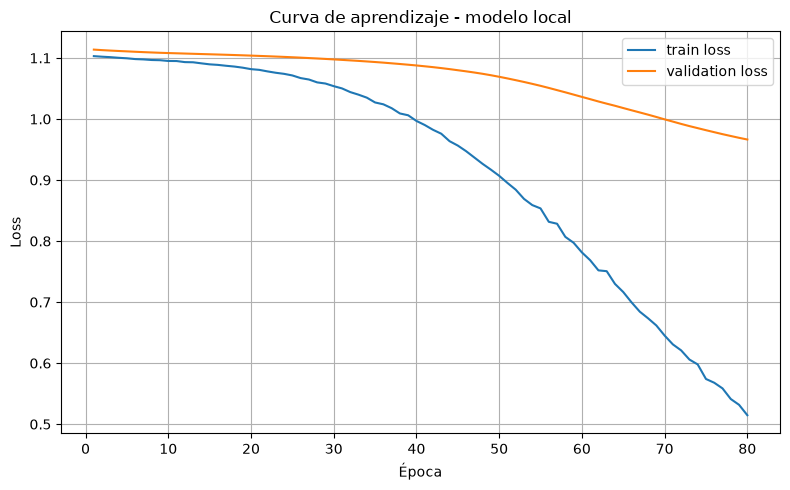


Evaluación modelo local FP32: accuracy=0.5000, f1_macro=0.4488
              precision    recall  f1-score   support

    negativo       0.33      0.25      0.29         4
      neutro       0.57      1.00      0.73         4
    positivo       0.50      0.25      0.33         4

    accuracy                           0.50        12
   macro avg       0.47      0.50      0.45        12
weighted avg       0.47      0.50      0.45        12

Archivo guardado: resultados_practica_clase_6\resultado_modelo_local_fp32.csv

BLOQUE 3 - Cuantización dinámica INT8

Evaluación FP32: accuracy=0.5000, f1_macro=0.4488
              precision    recall  f1-score   support

    negativo       0.33      0.25      0.29         4
      neutro       0.57      1.00      0.73         4
    positivo       0.50      0.25      0.33         4

    accuracy                           0.50        12
   macro avg       0.47      0.50      0.45        12
weighted avg       0.47      0.50      0.45        12



C:\Users\jpach\AppData\Local\Temp\ipykernel_42492\3739214947.py:15: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model_int8 = torch.quantization.quantize_dynamic(



Evaluación INT8 cuantizado: accuracy=0.5000, f1_macro=0.4488
              precision    recall  f1-score   support

    negativo       0.33      0.25      0.29         4
      neutro       0.57      1.00      0.73         4
    positivo       0.50      0.25      0.33         4

    accuracy                           0.50        12
   macro avg       0.47      0.50      0.45        12
weighted avg       0.47      0.50      0.45        12

FP32 | batch=1 | latencia/batch=0.2175 ms | throughput=4596.65 ejemplos/s
INT8 | batch=1 | latencia/batch=1.7824 ms | throughput=561.06 ejemplos/s
Archivo guardado: resultados_practica_clase_6\comparacion_cuantizacion.csv

Comparación FP32 vs INT8:
         modelo  accuracy  f1_macro   size_mb  latencia_ms_batch1  \
0          FP32       0.5  0.448773  0.062078            0.217550   
1  INT8_dynamic       0.5  0.448773  0.020026            1.782353   

   throughput_ej_s  
0      4596.654134  
1       561.056231  


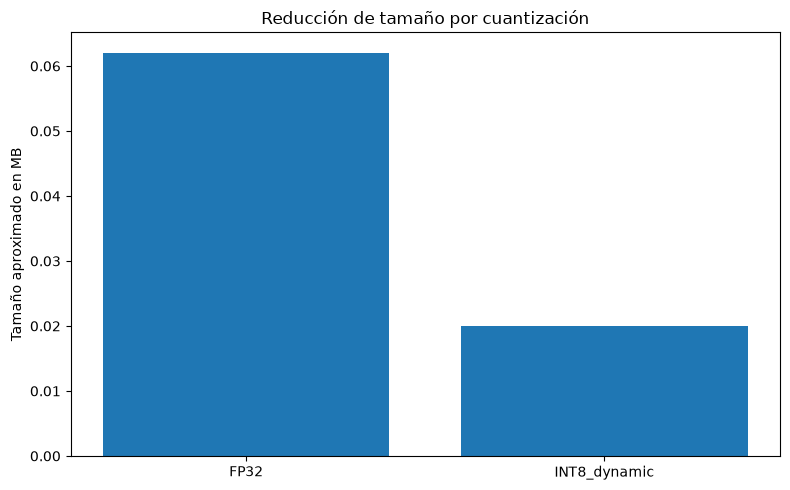

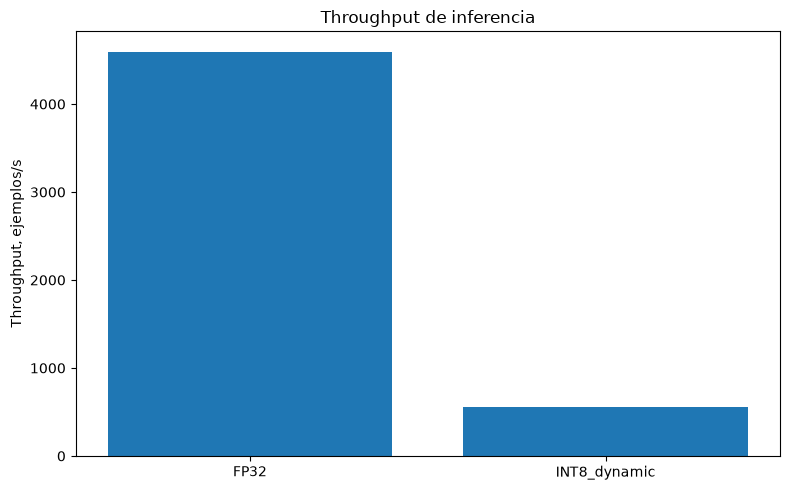


Preguntas para discusión de cuantización:
1. ¿El modelo INT8 redujo el tamaño? ¿Cuánto?
2. ¿Se mantuvo accuracy y F1 macro?
3. ¿La inferencia fue más rápida en este equipo?
4. ¿Por qué una técnica puede ayudar en un hardware y no en otro?

BLOQUE 4 - Inferencia optimizada: batching y throughput
FP32 | batch=1 | latencia/batch=0.2386 ms | throughput=4191.30 ejemplos/s
FP32 | batch=2 | latencia/batch=0.3865 ms | throughput=5174.84 ejemplos/s
FP32 | batch=4 | latencia/batch=0.2142 ms | throughput=18674.74 ejemplos/s
FP32 | batch=8 | latencia/batch=0.2502 ms | throughput=23976.92 ejemplos/s
FP32 | batch=16 | latencia/batch=0.2782 ms | throughput=43130.96 ejemplos/s
Archivo guardado: resultados_practica_clase_6\batching_throughput.csv
   batch_size  latencia_ms_por_batch  throughput_ej_s
0           1               0.238590      4191.296940
1           2               0.386486      5174.837044
2           4               0.214193     18674.740788
3           8               0.250241     23

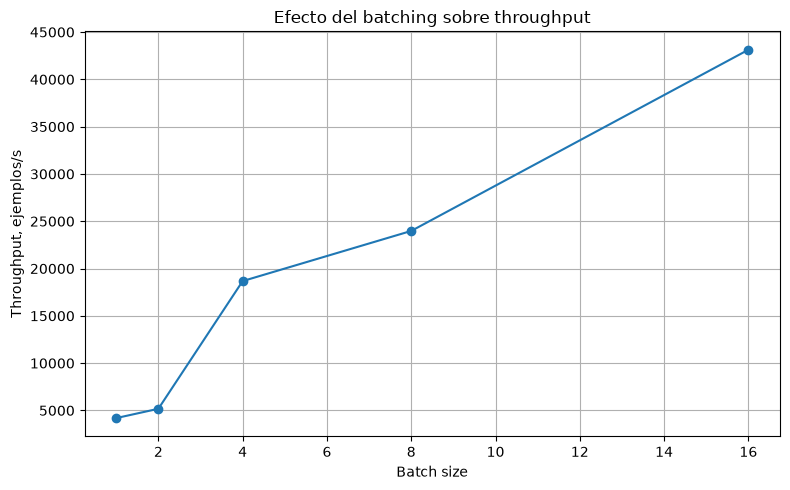


Preguntas para discusión de batching:
1. ¿Aumentó el throughput al incrementar el batch?
2. ¿Qué diferencia hay entre latencia individual y throughput global?
3. ¿En qué escenarios conviene batch grande y en cuáles no?

BLOQUE 5 - ONNX y ONNX Runtime


C:\Users\jpach\AppData\Local\Temp\ipykernel_42492\1205457446.py:27: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0718 12:11:53.596000 42492 site-packages\torch\onnx\_internal\exporter\_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 13 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `TinyTextClassifier([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `TinyTextClassifier([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


c:\Users\jpach\AppData\Local\Programs\Python\Python312\Lib\copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 13).
Failed to convert the model to the target version 13 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "c:\Users\jpach\AppData\Local\Programs\Python\Python312\Lib\site-packages\onnxscript\version_converter\__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\jpach\AppData\Local\Programs\Python\Python312\Lib\site-packages\onnxscript\version_converter\_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Modelo exportado a ONNX: resultados_practica_clase_6\tiny_text_classifier.onnx
ONNX Runtime | accuracy=0.5000 | f1_macro=0.4488 | throughput=301169.54 ejemplos/s
Archivo guardado: resultados_practica_clase_6\resultado_onnx_runtime.csv

Preguntas para discusión ONNX:
1. ¿La salida ONNX conserva la misma calidad que PyTorch?
2. ¿Qué ventajas tiene un formato portable?
3. ¿Qué habría que validar antes de usar ONNX en producción?

BLOQUE 6 - Plantillas conceptuales para GPTQ, AWQ y vLLM

[Plantilla conceptual: GPTQ]
- Se usa principalmente como cuantización post-entrenamiento para LLMs.
- Flujo típico:
    1. Cargar modelo ya entrenado.
    2. Proporcionar datos de calibración.
    3. Cuantizar pesos a 4-bit u 8-bit.
    4. Evaluar calidad, memoria y latencia.

Ejemplo orientativo

In [16]:
# ============================================================
# 9. EJECUCIÓN PRINCIPAL
# ============================================================


def main():
    # 1. LoRA opcional
    lora_result = None
    if RUN_HF_LORA:
        lora_result = run_lora_huggingface()
    else:
        print("\nBloque LoRA desactivado. Cambia RUN_HF_LORA=True para ejecutarlo.")

    # 2. Modelo local
    local_model = train_local_model()
    acc_local, f1_local, preds_local = evaluate_torch_model(local_model, X_test, y_test, name="modelo local FP32")

    # Guardar reporte base local
    local_report = pd.DataFrame([
        {
            "experimento": "modelo_local_FP32",
            "accuracy": acc_local,
            "f1_macro": f1_local,
            "size_mb": model_size_mb(local_model.to("cpu")),
        }
    ])
    save_dataframe(local_report, "resultado_modelo_local_fp32.csv")

    # 3. Cuantización
    quantized_model, quant_results = run_quantization_demo(local_model)

    # 4. Batching
    batching_results = run_batching_demo(local_model)

    # 5. ONNX opcional
    if RUN_ONNX_DEMO:
        onnx_result = run_onnx_demo(local_model)
    else:
        onnx_result = None

    # 6. Plantillas de técnicas avanzadas
    print_advanced_templates()

    # 7. Resumen final
    print("\n" + "=" * 70)
    print("RESUMEN FINAL DE LA PRÁCTICA")
    print("=" * 70)
    print("Archivos generados en:", OUTPUT_DIR.resolve())
    print("\nArchivos principales:")
    for path in sorted(OUTPUT_DIR.glob("*")):
        print("-", path.name)

    if lora_result is not None:
        print("\nResultado LoRA resumido:")
        print(lora_result)


if __name__ == "__main__":
    main()